In [1]:
import sympy as smp
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import matplotlib.animation as anim

![system](./rail-system.png)

In [2]:
t, m, K, k, om, r0 = smp.symbols(r"t m K k \omega r_0", real=True)
xk, xr = smp.symbols(r"x_k x_r", cls=smp.Function)
xk = xk(t)
xr = xr(t)

def dt(x):
    return smp.diff(x), smp.diff(smp.diff(x))

xk_d, xk_dd = dt(xk)
xr_d, xr_dd = dt(xr)

In [3]:
x = xr * smp.cos(t * om) - xk * smp.sin(t * om)
y = xr * smp.sin(t * om) + xk * smp.cos(t * om)

x_d = smp.diff(x, t)
y_d = smp.diff(y, t)

In [4]:
I = m * (x**2 + y**2)
I.simplify()

m*(x_k(t)**2 + x_r(t)**2)

In [5]:
T = 1 / 2 * m * (x_d**2 + y_d**2) + 1 / 2 * I * om**2
T.simplify()

0.5*m*(2*\omega**2*x_k(t)**2 + 2*\omega**2*x_r(t)**2 - 2*\omega*x_k(t)*Derivative(x_r(t), t) + 2*\omega*x_r(t)*Derivative(x_k(t), t) + Derivative(x_k(t), t)**2 + Derivative(x_r(t), t)**2)

In [6]:
V = 1/2 * k * xk**2 + 1/2 * K * (xr - r0)**2
V

0.5*K*(-r_0 + x_r(t))**2 + 0.5*k*x_k(t)**2

In [7]:
E = T + V
E.simplify()

0.5*K*(r_0 - x_r(t))**2 + 0.5*\omega**2*m*(x_k(t)**2 + x_r(t)**2) + 0.5*k*x_k(t)**2 + 0.5*m*(\omega**2*x_k(t)**2 + \omega**2*x_r(t)**2 - 2*\omega*x_k(t)*Derivative(x_r(t), t) + 2*\omega*x_r(t)*Derivative(x_k(t), t) + Derivative(x_k(t), t)**2 + Derivative(x_r(t), t)**2)

In [8]:
L = T - V
L.simplify()

-0.5*K*(r_0 - x_r(t))**2 + 0.5*\omega**2*m*(x_k(t)**2 + x_r(t)**2) - 0.5*k*x_k(t)**2 + 0.5*m*(\omega**2*x_k(t)**2 + \omega**2*x_r(t)**2 - 2*\omega*x_k(t)*Derivative(x_r(t), t) + 2*\omega*x_r(t)*Derivative(x_k(t), t) + Derivative(x_k(t), t)**2 + Derivative(x_r(t), t)**2)

# Compute the Jacobi's integral

We can see that $L$ does not depend on time explicitely, so $h$ (Jacobi) is conserved.

In [9]:
def energy_funcion(L, vars):
    h = -L
    for q in vars:
        q_d = smp.diff(q)
        
        h += q_d * smp.diff(L, q_d)

    return h

In [10]:
h = energy_funcion(L, (xr, xk))
h.simplify()

0.5*K*r_0**2 - 1.0*K*r_0*x_r(t) + 0.5*K*x_r(t)**2 - 1.0*\omega**2*m*x_k(t)**2 - 1.0*\omega**2*m*x_r(t)**2 + 0.5*k*x_k(t)**2 + 0.5*m*Derivative(x_k(t), t)**2 + 0.5*m*Derivative(x_r(t), t)**2

# Solving Lagrage's equations

In [11]:
def lagrange_eq(L, variables, R=0):
    lagrange_equations = []

    for q in variables:
        q_dot = smp.diff(q, t)
        LE = smp.diff(smp.diff(L, q_dot), t) - smp.diff(L, q) + smp.diff(R, q_dot)
        LE = LE.simplify()
        lagrange_equations.append(LE)
        
    return tuple(lagrange_equations)

In [12]:
LExr, LExk = lagrange_eq(L, (xr, xk))

In [13]:
LExr

-1.0*K*r_0 + 1.0*K*x_r(t) - 2.0*\omega**2*m*x_r(t) - 2.0*\omega*m*Derivative(x_k(t), t) + 1.0*m*Derivative(x_r(t), (t, 2))

In [14]:
LExk

-2.0*\omega**2*m*x_k(t) + 2.0*\omega*m*Derivative(x_r(t), t) + 1.0*k*x_k(t) + 1.0*m*Derivative(x_k(t), (t, 2))

Get a sytem of differential equations

In [15]:
sols = smp.solve([LExr, LExk], [xr_dd, xk_dd], simplify=False)

In [16]:
sols[xr_dd]

K*r_0/m - K*x_r(t)/m + 2.0*\omega**2*x_r(t) + 2.0*\omega*Derivative(x_k(t), t)

In [17]:
sols[xk_dd]

2.0*\omega**2*x_k(t) - 2.0*\omega*Derivative(x_r(t), t) - k*x_k(t)/m

# Solve the differential equations

In [18]:
dxrdt_f = smp.lambdify(xr_d, xr_d)
ddxrdt_f = smp.lambdify((K, r0, m, om, xr, xk_d), sols[xr_dd])

dxkrdt = smp.lambdify(xk_d, xk_d)
ddxkdt_f = smp.lambdify((k, m, om, xk, xr_d), sols[xk_dd])

In [19]:
def dSdt(S, t, K, r0, m, om, k):
    xr, xr_d, xk, xk_d = S
    return [
        dxrdt_f(xr_d),
        ddxrdt_f(K, r0, m, om, xr, xk_d),
        dxkrdt(xk_d),
        ddxkdt_f(k, m, om, xk, xr_d),
    ]

In [20]:
tf = 5
t_steps = 1000
t = np.linspace(0, tf, t_steps)

K = 2
k = 1
m = 0.01
om = 1.5 * np.pi

r0 = 1

In [21]:
s = odeint(dSdt, y0=[r0, 0, 0, 0], t=t, args=(K, r0, m, om, k))

In [22]:
xr_t = s.T[0]
xk_t = s.T[2]

x_t = xr_t * np.cos(t * om) - xk_t * np.sin(t * om)
y_t = xr_t * np.sin(t * om) + xk_t * np.cos(t * om)

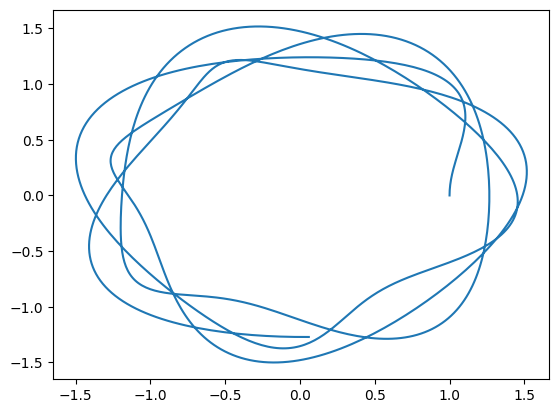

In [23]:
# plt.grid()
plt.plot(x_t, y_t)
s = 2
# plt.ylim((-r0 * s, r0 * s))
# plt.xlim((-r0 * s, r0 * s))

In [ ]:
def shaft(f):
    a = [
        xr_t[f] * np.cos(t[f] * om),
        xr_t[f] * np.sin(t[f] * om),
    ]
    
    b = [
        xr_t[f] * np.cos(t[f] * om) - xk_t[f] * np.sin(t[f] * om),
        xr_t[f] * np.sin(t[f] * om) + xk_t[f] * np.cos(t[f] * om),
    ]

    return np.array([[0, 0], a, b]).T
    
fig, ax = plt.subplots()
ball, = ax.plot(0, 0, color="black")
shaft_ax, = ax.plot(*shaft(0), "r--", lw=2, marker="o", markersize=6)

s = 3
ax.set_ylim((-r0 * s, r0 * s))
ax.set_xlim((-r0 * s, r0 * s))

fps = int(t_steps / tf)


def update(t):
    last_second = max(t - fps, 0)

    ball.set_data(x_t[last_second : t + 1], y_t[last_second : t + 1])
    shaft_ax.set_data(*shaft(t))

    return (
        ball,
        shaft_ax,
    )


animation = anim.FuncAnimation(
    fig,
    update,
    frames=len(x_t),
    blit=True,
    interval=fps,
)

writer = anim.FFMpegWriter(fps=fps)

![gif](./rotating-rails-animation.gif)

In [ ]:
animation.save("rotating-rails-animation.mp4", writer=writer)

In [ ]:
animation.save("rotating-rails-animation.gif", writer=writer)